### Anchor User 정의 & 5단계 투자 성향 라벨링

SCF 데이터에서 금융 이력이 있는 Anchor User를 정의하고,  
총 금융자산 대비 위험자산 비중(Risk Ratio)을 기반으로 5단계 투자 성향 라벨(Ground Truth) 생성

---
**수식**:
$\text{Risk Ratio (\%)} = \frac{\text{EQUITY}}{\text{FIN}} \times 100$

5단계 투자 성향: Absolute Thresholds (금융권 표준 방식)

| 단계 | 투자 성향 | Risk Ratio |
|------|-----------|------------|
| 1 | 매우 보수적 (Very Conservative) | 10% 미만 |
| 2 | 보수적 (Conservative) | 10% 이상 ~ 30% 미만 |
| 3 | 중도형 (Moderate) | 30% 이상 ~ 50% 미만 |
| 4 | 공격적 (Aggressive) | 50% 이상 ~ 70% 미만 |
| 5 | 매우 공격적 (Very Aggressive) | 70% 이상 |

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

In [30]:
df = pd.read_csv('../dataset/sub-data.csv')

print(f'전체 행(관측치) 수  : {len(df):,}')
print(f'전체 열(변수) 수    : {df.shape[1]}')
print('\n주요 금융 변수 기술 통계:')
key_cols = ['FIN', 'EQUITY', 'RETEQ', 'BOND', 'LIQ', 'CDS']
display(df[key_cols].describe())

전체 행(관측치) 수  : 14,678
전체 열(변수) 수    : 47

주요 금융 변수 기술 통계:


,FIN,EQUITY,RETEQ,BOND,LIQ,CDS
count,"14,677.00","14,677.00","14,677.00","14,677.00","14,677.00","14,677.00"
mean,"4,517,151.36","2,838,051.65","218,809.43","327,468.06","358,743.55","41,319.85"
std,"27,681,323.53","21,551,653.45","1,380,693.42","4,342,060.69","2,869,295.30","902,843.37"
min,910.00,0.00,0.00,0.00,1.00,0.00
25%,"15,110.00",0.00,0.00,0.00,"3,000.00",0.00
50%,"106,186.00","25,000.00","9,000.00",0.00,"12,520.00",0.00
75%,"691,300.00","298,800.00","110,400.00",0.00,"65,000.00",0.00
max,"1,029,603,400.00","986,850,300.00","87,727,999.98","276,827,999.92","193,239,667.99","98,628,000.00"


#### Anchor User 선정

Log-scale Stratified Sampling

```
구간별 사용자 수 (FIN > 0: 14,677명)
├── 구간1: 1만원 미만     → 2,972명 (20.2%)
├── 구간2: 5만원 미만     → 2,813명 (19.2%)  
├── 구간3: 20만원 미만    → 2,825명 (19.2%)
├── 구간4: 100만원 미만   → 2,943명 (20.1%)
└── 구간5: 100만원 이상   → 3,124명 (21.3%)
```

In [31]:
# Stratified Sampling으로 Anchor User 선정 (금융 자산 규모별 균형)

# Log-scale bins: 각 구간에서 균등 샘플링 (대표성 확보)
bins = [0, 10000, 50000, 200000, 1000000, np.inf]
anchor_df = df[df['FIN'] > 0].copy()
anchor_df['fin_bin'] = pd.cut(anchor_df['FIN'], bins=bins, right=False)

SAMPLE_PER_BIN = 100
anchor_sampled = (
    anchor_df
    .groupby('fin_bin', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), SAMPLE_PER_BIN), random_state=1))
)
anchor_df.drop(columns=['fin_bin'], inplace=True)

n_sampled = len(anchor_sampled)
print(f'전체 사용자 (FIN>0)  : {len(anchor_df):,}명')
print(f'Anchor User (샘플링) : {n_sampled:,}명')
print('\n구간별 샘플링 결과:')
display(
    anchor_sampled['FIN']
    .groupby(pd.cut(anchor_sampled['FIN'], bins=bins))
    .size()
    .to_frame('선정 사용자 수')
)
print(f'\n✅ {n_sampled}명 Anchor User로 라벨링 진행 (각 구간 {SAMPLE_PER_BIN}명 균등 샘플링)')

전체 사용자 (FIN>0)  : 14,677명
Anchor User (샘플링) : 500명

구간별 샘플링 결과:


,선정 사용자 수
FIN,
"(0.0, 10000.0]",100
"(10000.0, 50000.0]",100
"(50000.0, 200000.0]",100
"(200000.0, 1000000.0]",100
"(1000000.0, inf]",100



✅ 500명 Anchor User로 라벨링 진행 (각 구간 100명 균등 샘플링)


#### Risk Ratio 계산

$\text{Risk Ratio (\%)} = \frac{\text{EQUITY}}{\text{FIN}} \times 100$

`RETEQ`(은퇴 계좌 내 주식 비중)를 더한 `risk_ratio_ext = (EQUITY + RETEQ) / FIN * 100` 수식도 함께 산출

In [32]:
# 기본 Risk Ratio: EQUITY / FIN
anchor_df['RISK_RATIO'] = (anchor_df['EQUITY'] / anchor_df['FIN'] * 100).clip(0, 100)

# 확장 Risk Ratio: (EQUITY + RETEQ) / FIN  (은퇴자산 내 주식 포함)
anchor_df['RISK_RATIO_EXT'] = (
    (anchor_df['EQUITY'] + anchor_df['RETEQ']) / anchor_df['FIN'] * 100
).clip(0, 100)

print('Risk Ratio 기술 통계:')
display(anchor_df[['RISK_RATIO', 'RISK_RATIO_EXT']].describe())

print('\n분포 요약 (Percentile):')
pcts = [0, 10, 25, 50, 75, 90, 95, 100]
display(anchor_df[['RISK_RATIO', 'RISK_RATIO_EXT']].quantile([p/100 for p in pcts]))

Risk Ratio 기술 통계:


,RISK_RATIO,RISK_RATIO_EXT
count,"14,677.00","14,677.00"
mean,32.98,46.02
std,30.64,38.96
min,0.00,0.00
25%,0.00,0.00
50%,28.18,45.50
75%,56.57,84.80
max,99.99,100.00



분포 요약 (Percentile):


,RISK_RATIO,RISK_RATIO_EXT
0.00,0.00,0.00
0.10,0.00,0.00
0.25,0.00,0.00
0.50,28.18,45.50
0.75,56.57,84.80
0.90,79.84,100.00
0.95,90.15,100.00
1.00,99.99,100.00


#### 5단계 투자 성향 라벨링

| 단계 | 성향 | 기준 |
|------|------|------|
| 1 | 매우 보수적 | Risk Ratio < 10% |
| 2 | 보수적 | 10% ≤ Risk Ratio < 30% |
| 3 | 중도형 | 30% ≤ Risk Ratio < 50% |
| 4 | 공격적 | 50% ≤ Risk Ratio < 70% |
| 5 | 매우 공격적 | Risk Ratio ≥ 70% |

In [33]:
def assign_RISK_LABEL(ratio: pd.Series) -> pd.Series:
    """5단계 투자 성향 라벨링"""
    bins   = [-np.inf, 10, 30, 50, 70, np.inf]
    labels = [1, 2, 3, 4, 5]
    return pd.cut(ratio, bins=bins, labels=labels, right=False).astype(int)

anchor_df['RISK_LABEL']     = assign_RISK_LABEL(anchor_df['RISK_RATIO'])
anchor_df['RISK_LABEL_EXT'] = assign_RISK_LABEL(anchor_df['RISK_RATIO_EXT'])

# 라벨명 매핑
label_names = {
    1: 'Very Conservative',
    2: 'Conservative',
    3: 'Moderate',
    4: 'Aggressive',
    5: 'Very Aggressive',
}
anchor_df['RISK_LABEL_NAME'] = anchor_df['RISK_LABEL'].map(label_names)

# 분포 확인
label_dist = (
    anchor_df['RISK_LABEL']
    .value_counts()
    .sort_index()
    .rename('Number of Users')
    .to_frame()
)

n_anchor = len(anchor_df)
label_dist['Percentage (%)'] = (label_dist['Number of Users'] / n_anchor * 100).round(2)
label_dist['Risk Tolerance']      = label_dist.index.map(label_names)
label_dist = label_dist[['Risk Tolerance', 'Number of Users', 'Percentage (%)']]

print('▶ 5단계 투자 성향 라벨 분포 (EQUITY / FIN 기준)')
display(label_dist)

▶ 5단계 투자 성향 라벨 분포 (EQUITY / FIN 기준)


,Risk Tolerance,Number of Users,Percentage (%)
RISK_LABEL,,,
1,Very Conservative,5108,34.80
2,Conservative,2468,16.82
3,Moderate,2657,18.10
4,Aggressive,2188,14.91
5,Very Aggressive,2256,15.37


#### Sanity Check — Survey Bias 검증 (YESFINRISK × risk_label)

In [34]:
# YESFINRISK: 1=재무 위험 감수 의향 있음, NOFINRISK: 1=위험 감수 없음
sanity = (
    anchor_df.groupby('RISK_LABEL')[['YESFINRISK', 'NOFINRISK']]
    .mean()
    .round(3)
    * 100
)
sanity.index = [label_names[i] for i in sanity.index]
sanity.columns = ['YESFINRISK 비율(%)', 'NOFINRISK 비율(%)']

print('▶ Sanity Check: 단계별 설문 응답 비율')
print('  → 5단계(매우 공격적)일수록 YESFINRISK가 높아야 정합성이 있음')
print('  → 반대 패턴이 관찰되면 → Survey Bias 존재의 강력한 증거')
display(sanity)

# 5단계에서 NOFINRISK 비율이 높은지 체크
stage5_no = anchor_df[anchor_df['RISK_LABEL'] == 5]['NOFINRISK'].mean() * 100
stage1_no = anchor_df[anchor_df['RISK_LABEL'] == 1]['NOFINRISK'].mean() * 100
print(f'\n  5단계(매우 공격적) 중 NOFINRISK 응답 비율: {stage5_no:.1f}%')
print(f'  1단계(매우 보수적) 중 NOFINRISK 응답 비율: {stage1_no:.1f}%')
if stage5_no > 20:
    print('  ⚠️  Survey Bias 의심: 실제 공격적 투자자임에도 설문에서 위험 기피로 응답한 비율이 유의미함!')
else:
    print('  ✅ 설문-행동 간 정합성 확인 (Survey Bias 낮음)')

▶ Sanity Check: 단계별 설문 응답 비율
  → 5단계(매우 공격적)일수록 YESFINRISK가 높아야 정합성이 있음
  → 반대 패턴이 관찰되면 → Survey Bias 존재의 강력한 증거


,YESFINRISK 비율(%),NOFINRISK 비율(%)
Very Conservative,4.10,52.20
Conservative,3.90,28.00
Moderate,3.70,18.00
Aggressive,4.70,12.60
Very Aggressive,8.50,12.50



  5단계(매우 공격적) 중 NOFINRISK 응답 비율: 12.5%
  1단계(매우 보수적) 중 NOFINRISK 응답 비율: 52.2%
  ✅ 설문-행동 간 정합성 확인 (Survey Bias 낮음)


#### 분포 시각화

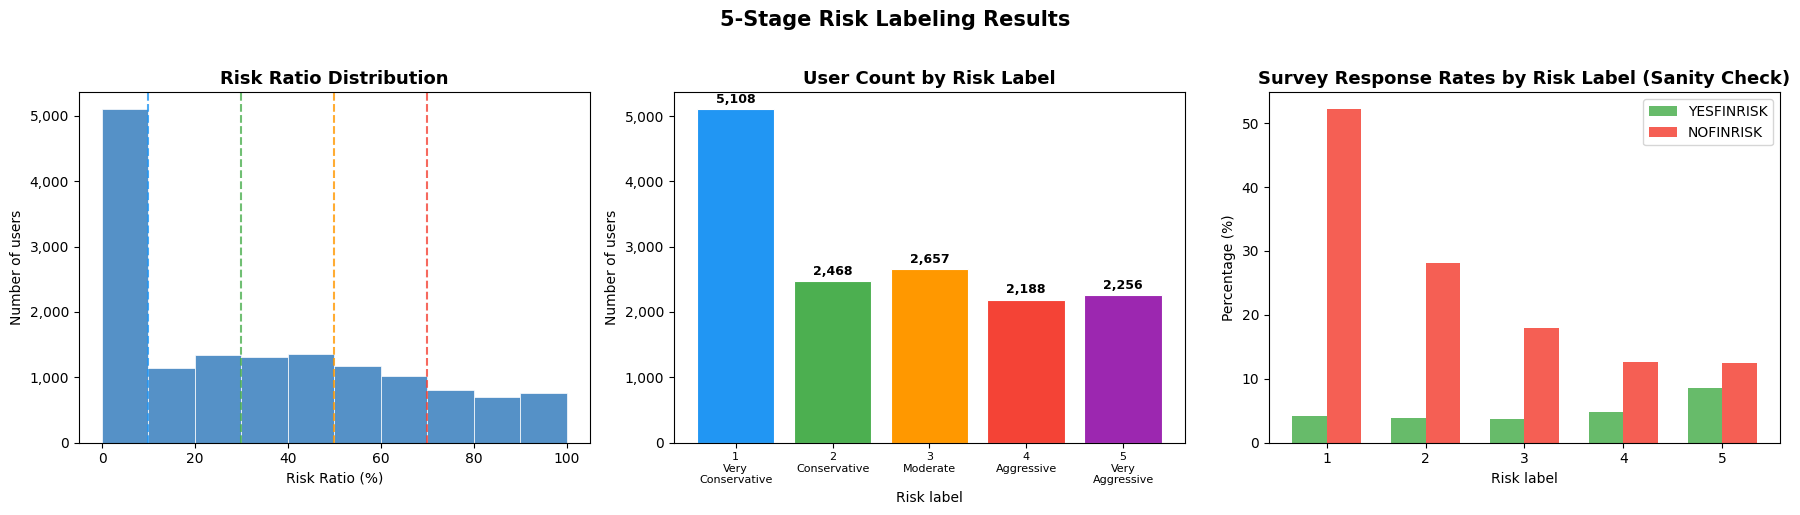

✅ Visualization saved: labeling_result.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

# (1) Risk Ratio histogram
ax1 = axes[0]
ax1.hist(anchor_df['RISK_RATIO'], bins=10, color='#5591c7', edgecolor='white', linewidth=0.5)
for x, c in zip([10, 30, 50, 70], ['#2196F3','#4CAF50','#FF9800','#F44336']):
    ax1.axvline(x, color=c, linestyle='--', linewidth=1.5, alpha=0.8)
ax1.set_title('Risk Ratio Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Risk Ratio (%)')
ax1.set_ylabel('Number of users')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# (2) User count by risk label
ax2 = axes[1]
counts = anchor_df['RISK_LABEL'].value_counts().sort_index()
bars = ax2.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('User Count by Risk Label', fontsize=13, fontweight='bold')
ax2.set_xlabel('Risk label')
ax2.set_ylabel('Number of users')
ax2.set_xticks([1,2,3,4,5])
ax2.set_xticklabels(['1\nVery\nConservative','2\nConservative','3\nModerate','4\nAggressive','5\nVery\nAggressive'], fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# (3) Sanity Check: YESFINRISK vs NOFINRISK by risk label
ax3 = axes[2]
grp = anchor_df.groupby('RISK_LABEL')[['YESFINRISK','NOFINRISK']].mean() * 100
x = np.arange(1, 6)
w = 0.35
ax3.bar(x - w/2, grp['YESFINRISK'], width=w, label='YESFINRISK', color='#4CAF50', alpha=0.85)
ax3.bar(x + w/2, grp['NOFINRISK'],  width=w, label='NOFINRISK',  color='#F44336', alpha=0.85)
ax3.set_title('Survey Response Rates by Risk Label (Sanity Check)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Risk label')
ax3.set_ylabel('Percentage (%)')
ax3.set_xticks(x)
ax3.legend()

plt.suptitle('5-Stage Risk Labeling Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('labeling_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualization saved: labeling_result.png')

#### 최종 Anchor Dataset 저장

In [37]:
# 저장할 컬럼 선정 (원본 변수 + 새로 생성한 라벨 변수)
output_cols = list(df.columns) + ['RISK_RATIO', 'RISK_RATIO_EXT', 'RISK_LABEL', 'RISK_LABEL_EXT', 'RISK_LABEL_NAME']

anchor_out = anchor_df[output_cols]
anchor_out.to_csv('../dataset/anchor_labeled_data.csv', index=False)

print(f'✅ 저장 완료: anchor_labeled_data.csv')
print(f'   행 수: {len(anchor_out):,} | 열 수: {len(output_cols)}')
print('\n▶ 최종 데이터 샘플 (5행):')
display(anchor_out[['CASEID','FIN','EQUITY','RETEQ','RISK_RATIO','RISK_LABEL','RISK_LABEL_NAME','YESFINRISK','NOFINRISK']].head())

✅ 저장 완료: anchor_labeled_data.csv
   행 수: 14,677 | 열 수: 52

▶ 최종 데이터 샘플 (5행):


,CASEID,FIN,EQUITY,RETEQ,RISK_RATIO,RISK_LABEL,RISK_LABEL_NAME,YESFINRISK,NOFINRISK
0,"145,156.00","164,874.00","120,740.00","7,340.00",73.23,5,Very Aggressive,0.00,1.00
1,"145,161.00","57,500.00","20,000.00","20,000.00",34.78,3,Moderate,0.00,1.00
2,"145,166.00","4,040.00",0.00,0.00,0.00,1,Very Conservative,0.00,1.00
3,"145,171.00","65,138.00",0.00,0.00,0.00,1,Very Conservative,0.00,1.00
4,"145,176.00","48,424.00","12,960.00","12,960.00",26.76,2,Conservative,0.00,1.00
